#Assignment 1

Max collaborators = 3

There is a bit of handholding. If you still do not understand something, feel free to reach out to your lab faculties. Good luck.

In [16]:
COLLABORATORS_NAME = "Imtiaz Hossain"
COLLABORATORS_ID = "23101137"

# Part 1 [15 Marks]

In this part, you will work with point processing, HE, AHE, and CLAHE.

In [17]:
import numpy as np
from skimage import io, color, exposure, img_as_float, transform
import matplotlib.pyplot as plt
### If you need other dependencies import here -
from scipy import signal
### Code ends

In [18]:
### If you need helper functions defined, define here -
def plot_hist(ax, data, title):
    ax.hist(data.ravel(), bins=256)
    ax.set_title(title)
    ax.set_xlabel("Pixel values")
    ax.set_ylabel("Frequency")

def plot_img_and_hist(img, axes, bins=256):
    img = img_as_float(img)
    ax_img, ax_hist = axes
    ax_cdf = ax_hist.twinx()

    ax_img.imshow(img, cmap=plt.cm.gray, vmin=0, vmax=1)
    ax_img.set_axis_off()

    ax_hist.hist(img.ravel(), bins=bins, histtype='step', color='black')
    ax_hist.ticklabel_format(axis='y', style='scientific', scilimits=(0, 0))
    ax_hist.set_xlabel('Pixel intensity')
    ax_hist.set_xlim(0, 1)
    ax_hist.set_yticks([])

    img_cdf, bins_cdf = exposure.cumulative_distribution(img, bins)
    ax_cdf.plot(bins_cdf, img_cdf, 'r')
    ax_cdf.set_yticks([])

    return ax_img, ax_hist, ax_cdf


### Code ends

## Task 1 - Basic Image Operation

Import any photograph taken by you (RGB) (`sample_1.jpeg`/`sample_1.jpg`) as a numpy array, save it in the varaible `I`.

A picture taken from your phone of any scenary/streets/building is better.

Remember - your image name MUST be `sample_1.jpeg`/`sample_1.jpg`.

Make sure the height and the width of the image is **smaller than 1000 pixels**.

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
I = io.imread("/content/drive/MyDrive/BracU 9th Semester/CSE428/Lab/Assignment/A1/Images/sample_1.jpg")

# find the height and the width of the image
H = I.shape[0] # should contain height
W = I.shape[1] # should contain width
print("Height is", H)
print("Width is", W)

Height is 925
Width is 1560


Resized Height is 592
Resized Width is 999


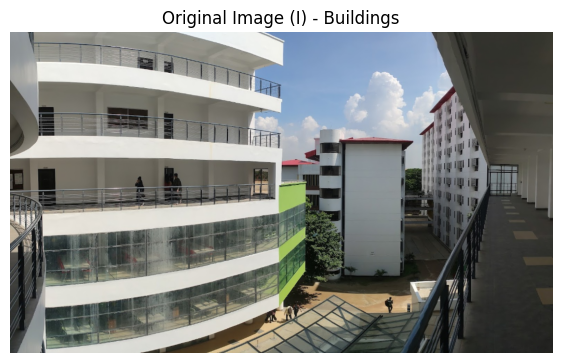

In [21]:
# Since my image size is above 1000 pixels.----> I will reshape it here.
# Here I am also maintaining aspect ratio

if H >= 1000 or W >= 1000:

    max_dimension = 999

    if H > W:
        new_H = max_dimension
        new_W = int(W * (max_dimension / H))

    else:
        new_W = max_dimension
        new_H = int(H * (max_dimension / W))


    I = transform.resize(I, (new_H, new_W), anti_aliasing=True)

    H = I.shape[0]
    W = I.shape[1]

    print(f"Resized Height is {H}")
    print(f"Resized Width is {W}")

else:
    I = img_as_float(I) # Replace none and normalize the image so that the pixel values of each channel are between 0 and 1

### Write a code to display the image -
plt.figure(figsize=(7, 7))
plt.imshow(I)
plt.title("Original Image (I) - Buildings")
plt.axis("off")
plt.show()
### Code ends

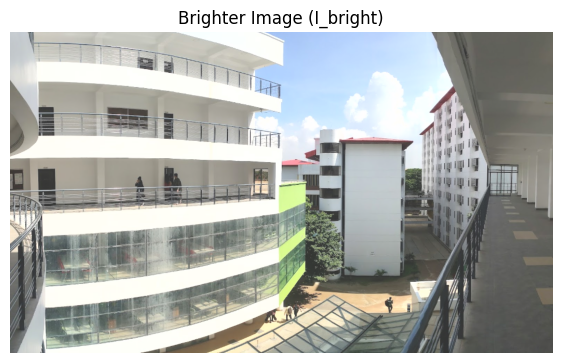

In [22]:
# Increase the brightness of the image without changing the contrast.
# Save the resulting image in I_bright.

I_lab = color.rgb2lab(I)
L_channel = I_lab[:, :, 0]
L_bright = L_channel + 20
L_bright = np.clip(L_bright, 0, 100)
I_lab_bright = I_lab.copy()
I_lab_bright[:, :, 0] = L_bright
I_bright = color.lab2rgb(I_lab_bright)
I_bright = np.clip(I_bright, 0, 1) # Clip final RGB to 0-1

### Hint - You have to convert to LAB first

### Write a code to display the I_bright -

plt.figure(figsize=(7, 7))
plt.imshow(I_bright)
plt.title("Brighter Image (I_bright)")
plt.axis("off")
plt.show()

### Code ends

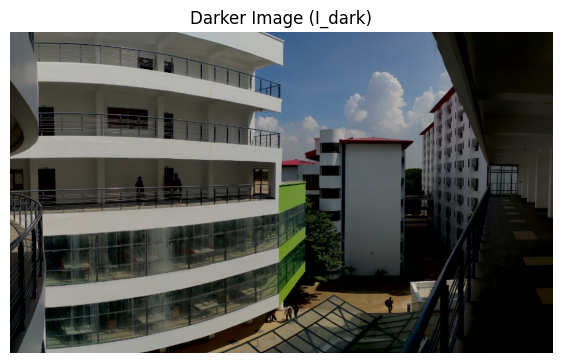

In [23]:
# Decrease the brightness of the image without changing the contrast.
# Save the resulting image in I_dark.

I_lab = color.rgb2lab(I)
L_channel = I_lab[:, :, 0]
L_dark = L_channel - 20
L_dark = np.clip(L_dark, 0, 100)
I_lab_dark = I_lab.copy()
I_lab_dark[:, :, 0] = L_dark
I_dark = color.lab2rgb(I_lab_dark)
I_dark = np.clip(I_dark, 0, 1)

### Write a code to display the I_bright -

plt.figure(figsize=(7, 7))
plt.imshow(I_dark)
plt.title("Darker Image (I_dark)")
plt.axis("off")
plt.show()

### Code ends

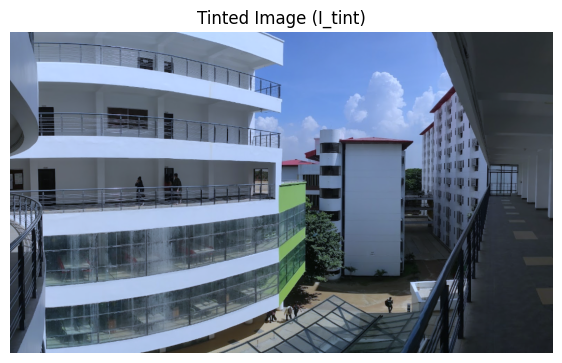

In [24]:
# Multiply the three channels of image I with three DIFFERENT numbers between 0.3 and 3
# Save the resulting image in I_tint and display it.
# The resulting image should have some color shift

I_tint = I.copy()

I_tint[:, :, 0] *= 0.8
I_tint[:, :, 1] *= 0.9
I_tint[:, :, 2] *= 1.1

I_tint = np.clip(I_tint, 0, 1)

### Write a code to display the I_tint -

plt.figure(figsize=(7, 7))
plt.imshow(I_tint)
plt.title("Tinted Image (I_tint)")
plt.axis("off")
plt.show()

### Code ends

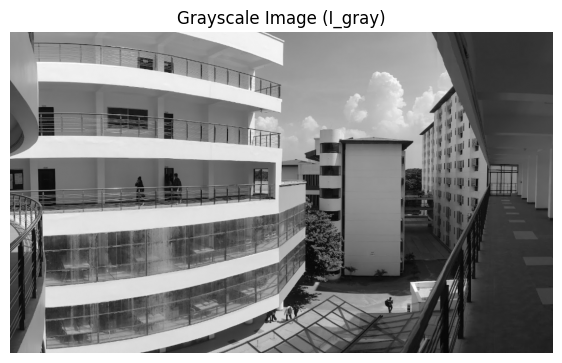

In [25]:
# Convert the image into a grayscale image.
# Save it to I_gray and display it

I_gray = color.rgb2gray(I)

### Write a code to display the I_gray -

plt.figure(figsize=(7, 7))
plt.imshow(I_gray, cmap='gray')
plt.title("Grayscale Image (I_gray)")
plt.axis("off")
plt.show()

### Code ends

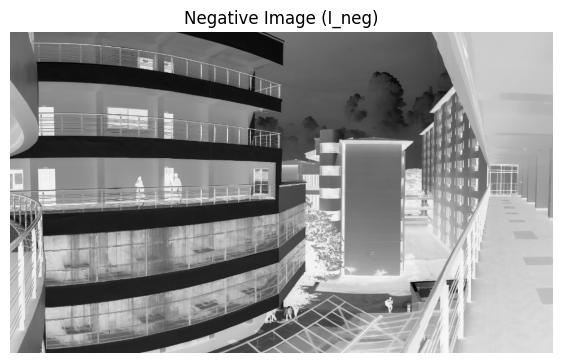

In [26]:
# Display the negative of the grayscale image

I_neg = 1.0 - I_gray

### Write a code to display the I_neg -

plt.figure(figsize=(7, 7))
plt.imshow(I_neg, cmap='gray')
plt.title("Negative Image (I_neg)")
plt.axis("off")
plt.show()

### Code ends

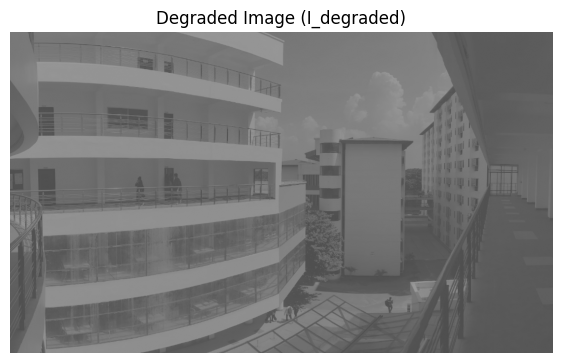

In [27]:
# This cell will artificially degrade your grayscale image by reducing contrast
# The max pixel value is mapped to 0.6 and the min pixel value is mapped to 0.3
I_degraded = exposure.rescale_intensity(I_gray, in_range=(0, 1), out_range=(0.3, 0.6))

# Try to understand what is going on
# You will need to use this concept later on

### Write a code to display the I_degraded -

# If you use plt.imshow(), set vmin = 0, vmax = 1

plt.figure(figsize=(7, 7))
plt.imshow(I_degraded, cmap='gray', vmin=0, vmax=1)
plt.title("Degraded Image (I_degraded)")
plt.axis("off")
plt.show()

### Code ends

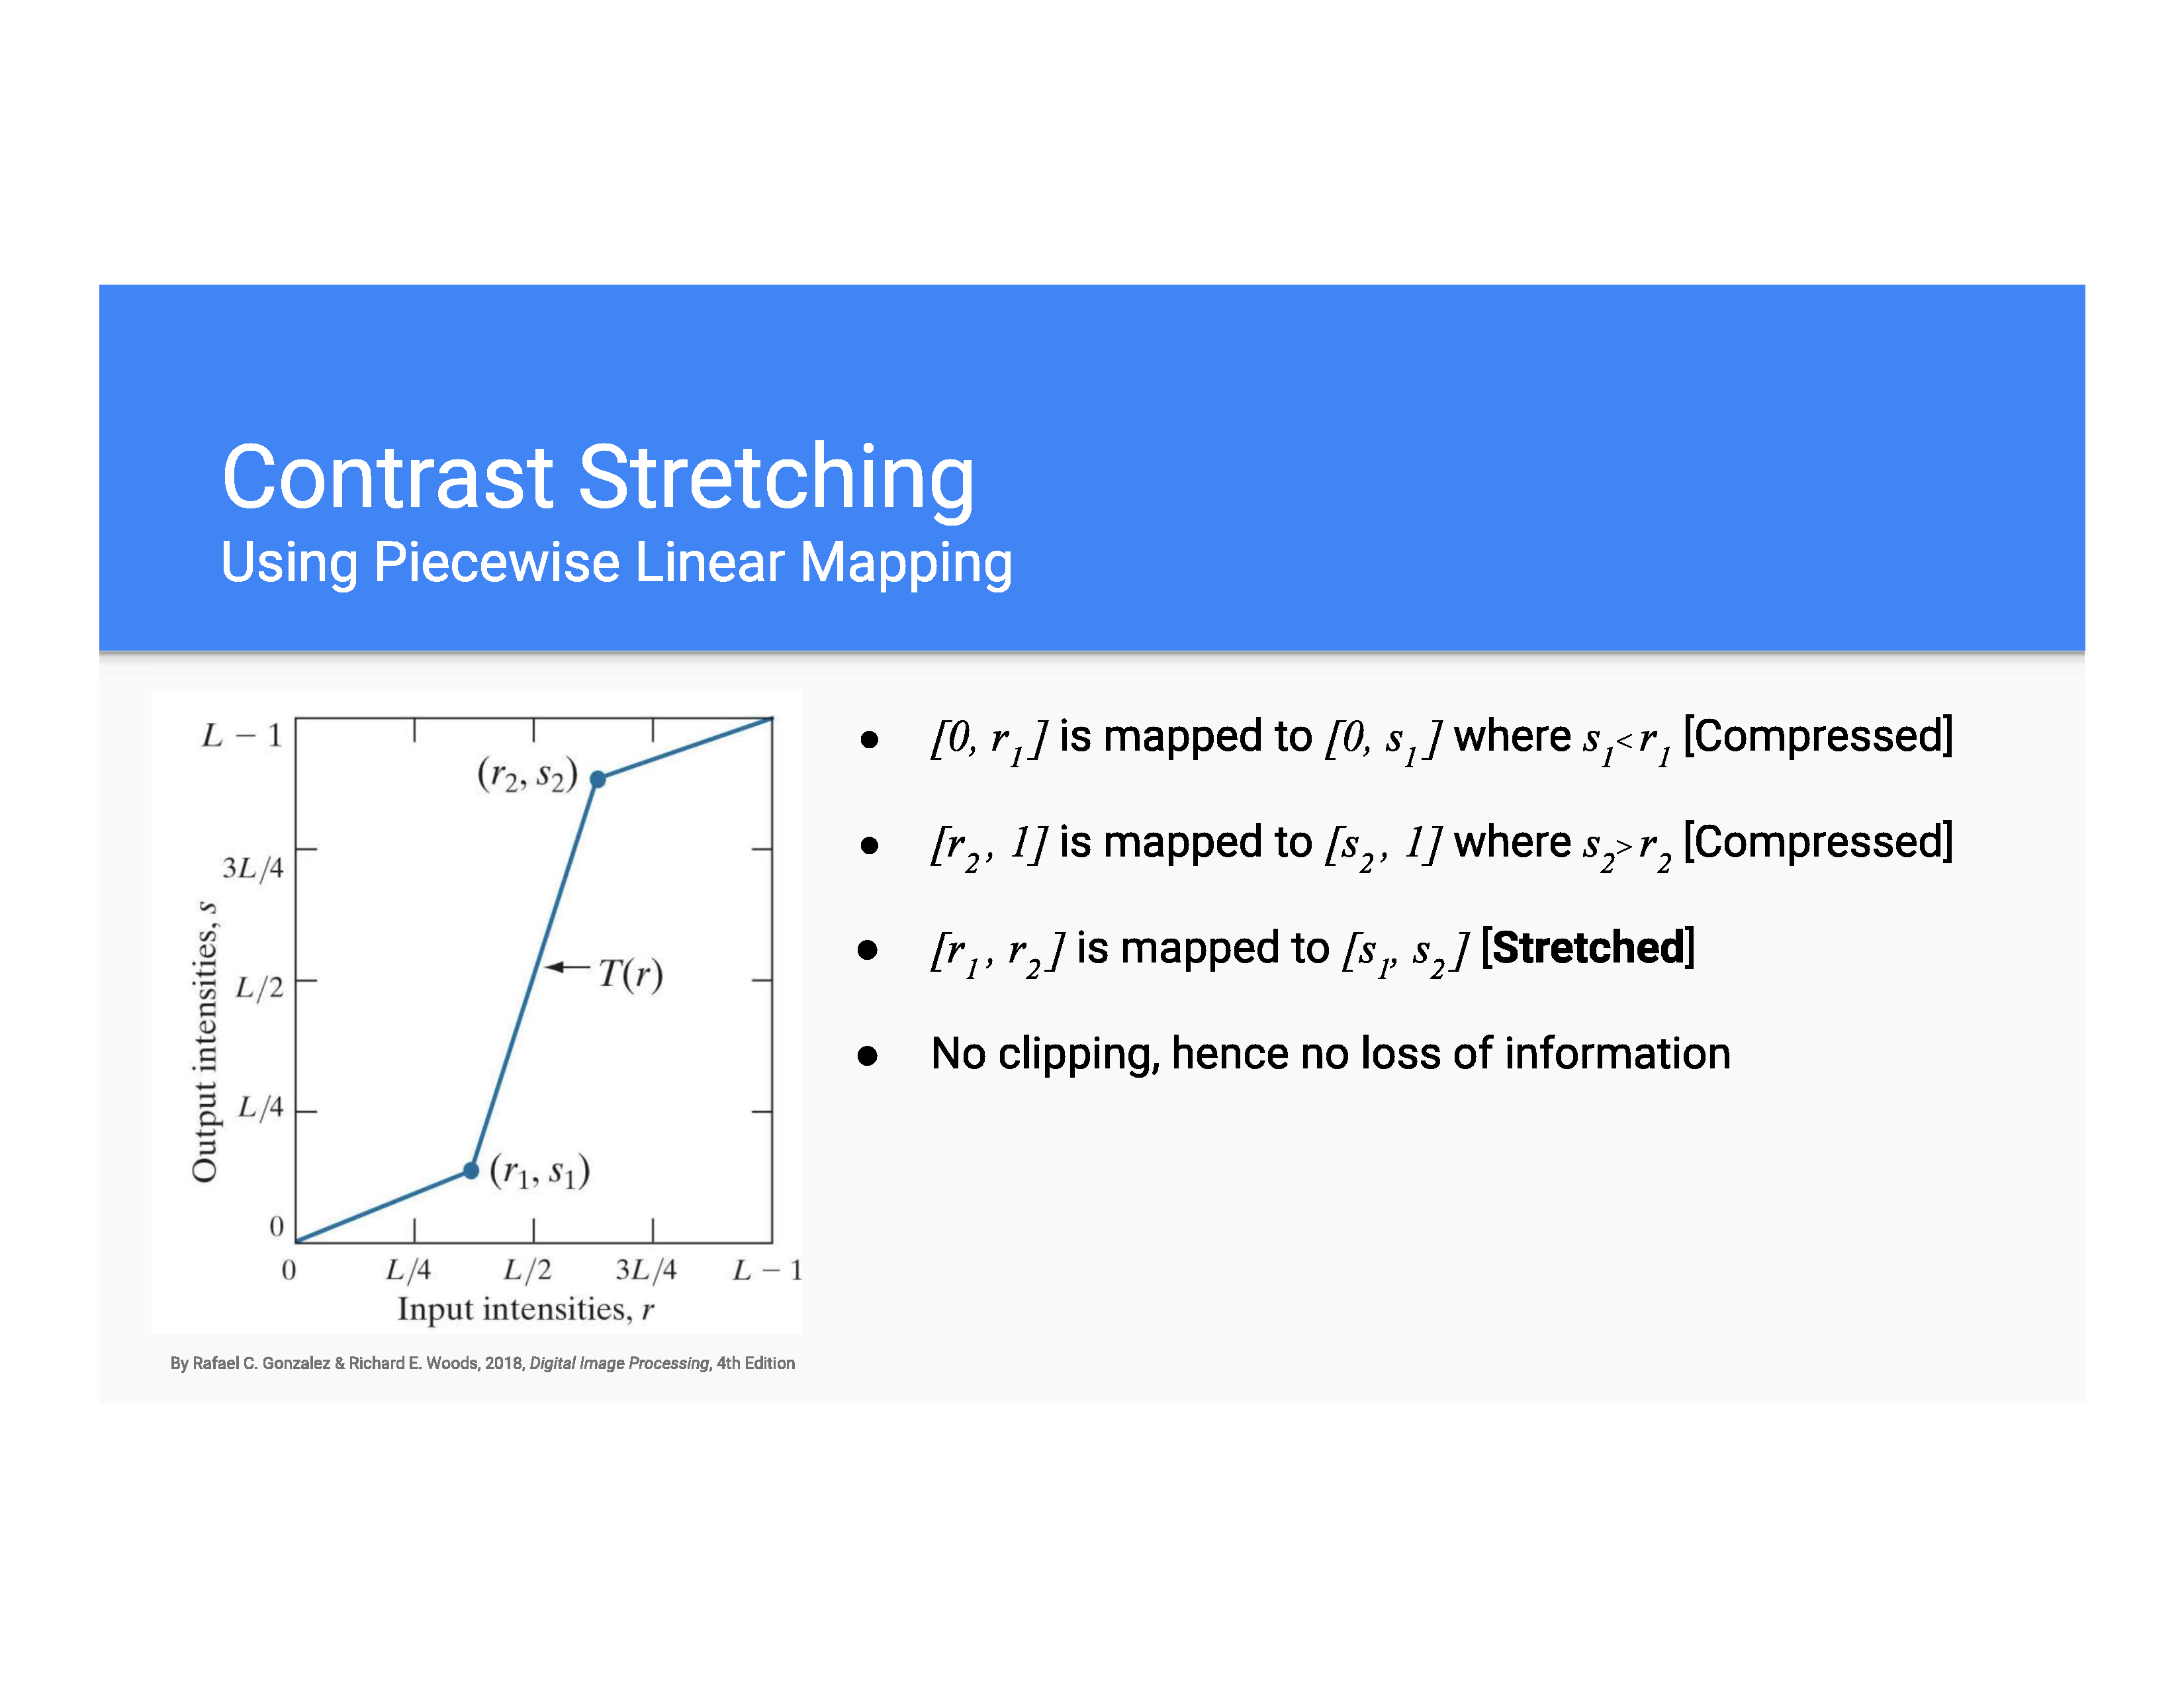

In [28]:
# Complete the following function to perform Piecewise Linear Contrast stretching
# That is, implement the map shown in the picture above

# Assume both input and output images are normalized between 0 and 1

def piecewise_contrast_stretch(I, r1, r2, s1, s2):

    I_out = np.copy(I)

    mask1 = I < r1
    mask2 = (I >= r1) & (I <= r2)
    mask3 = I > r2

    if r1 != 0:
        m1 = s1 / r1
    else:
        m1 = 0

    if (r2 - r1) != 0:
        m2 = (s2 - s1) / (r2 - r1)
    else:
        m2 = 0

    if (1.0 - r2) != 0:
        m3 = (1.0 - s2) / (1.0 - r2)
    else:
        m3 = 0

    I_out[mask1] = m1 * I[mask1]
    I_out[mask2] = m2 * (I[mask2] - r1) + s1
    I_out[mask3] = m3 * (I[mask3] - r2) + s2

    I_stretched = np.clip(I_out, 0, 1)

    return I_stretched

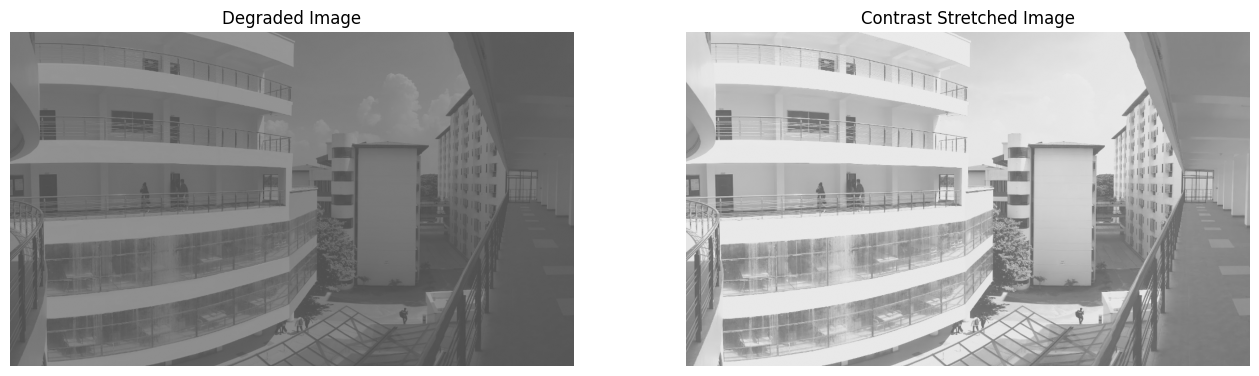

In [29]:
# To test your implementation, contrast strech the degraded image I_degrade to fix it
r1 = 0.2
r2 = 0.5
s1 = 0.1
s2 = 0.9
I_stretched = piecewise_contrast_stretch(I_degraded, r1, r2, s1, s2)

### Write a code to display the I_stretched -

fig, ax = plt.subplots(1, 2, figsize=(16, 8))

ax[0].imshow(I_degraded, cmap='gray', vmin=0, vmax=1)
ax[0].set_title("Degraded Image")
ax[0].axis('off')

ax[1].imshow(I_stretched, cmap='gray', vmin=0, vmax=1)
ax[1].set_title("Contrast Stretched Image")
ax[1].axis('off')
plt.show()

### Code ends

## Task 2 - Histogram and Equalization


--- Plotting Original Color Image (I) ---


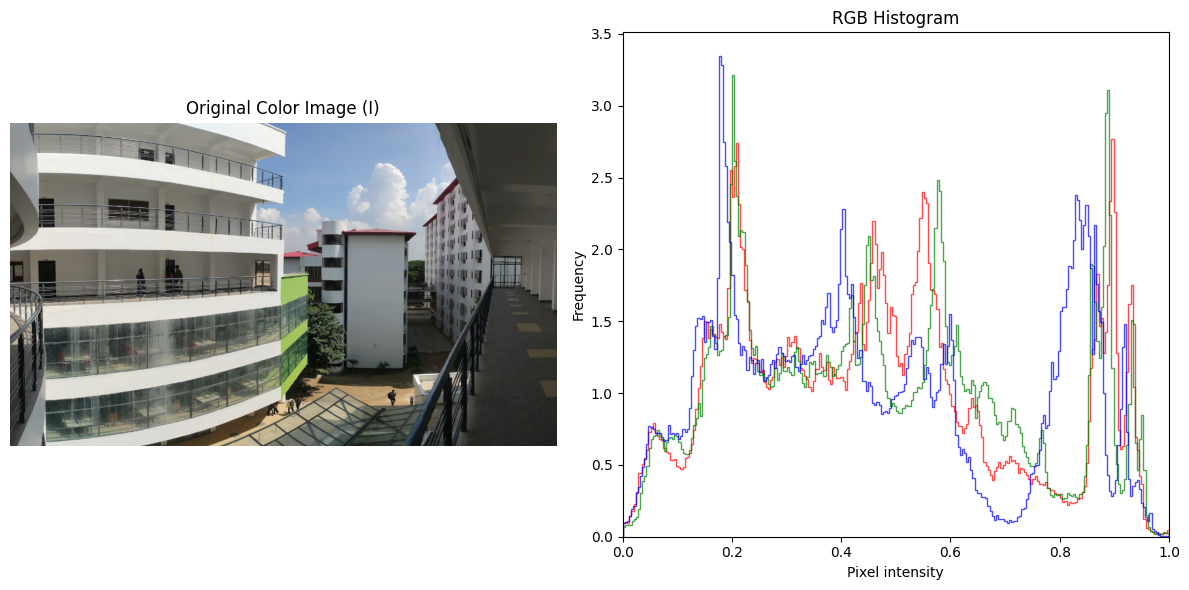

In [30]:
# Plot the image and its histogram + cdf of the original image I
# Note that it is a color image, so it will have three different histograms

### Begin solution

print("\n--- Plotting Original Color Image (I) ---")
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Display the image
axes[0].imshow(I)
axes[0].set_title("Original Color Image (I)")
axes[0].axis('off')

ax_hist = axes[1]

for channel, color_name in zip(I.transpose(2, 0, 1), ('red', 'green', 'blue')):
    ax_hist.hist(channel.ravel(), bins=256, color=color_name, alpha=0.7, histtype='step', density=True)

ax_hist.set_title("RGB Histogram")
ax_hist.set_xlabel("Pixel intensity")
ax_hist.set_ylabel("Frequency")
ax_hist.set_xlim(0, 1)
plt.tight_layout()
plt.show()

### End solution


--- Plotting Grayscale Image (I_gray) ---


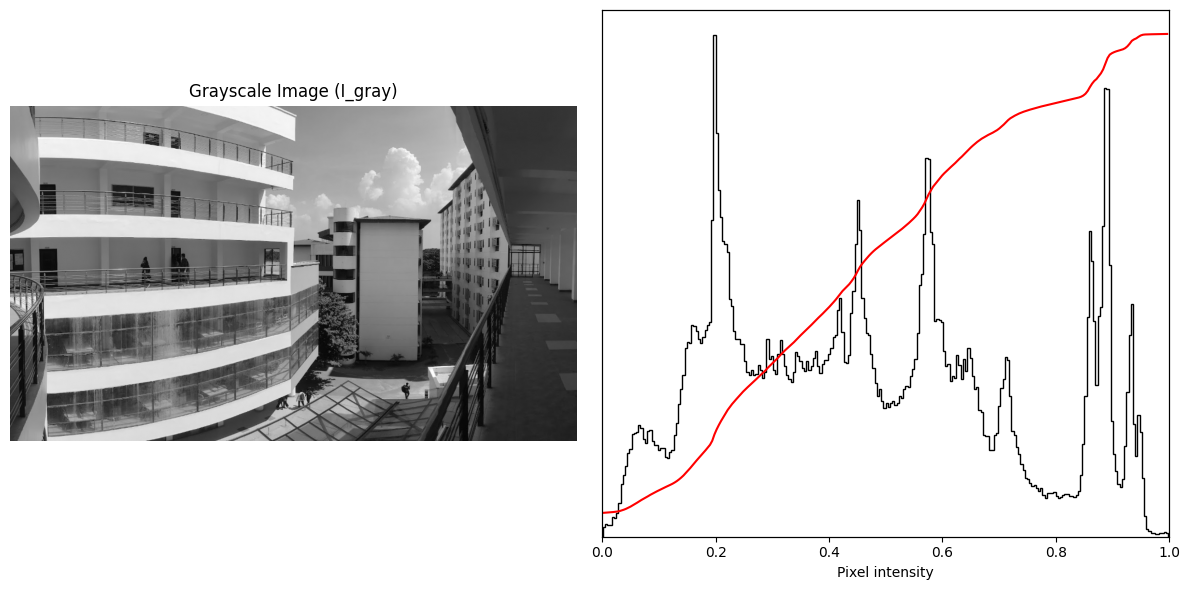

In [31]:
# Plot the grayscale image, I_gray, and its histogram + cdf

### Begin solution

print("\n--- Plotting Grayscale Image (I_gray) ---")
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
plot_img_and_hist(I_gray, axes)
axes[0].set_title("Grayscale Image (I_gray)")
plt.tight_layout()
plt.show()

### End solution


--- Plotting Degraded Grayscale Image (I_degraded) ---


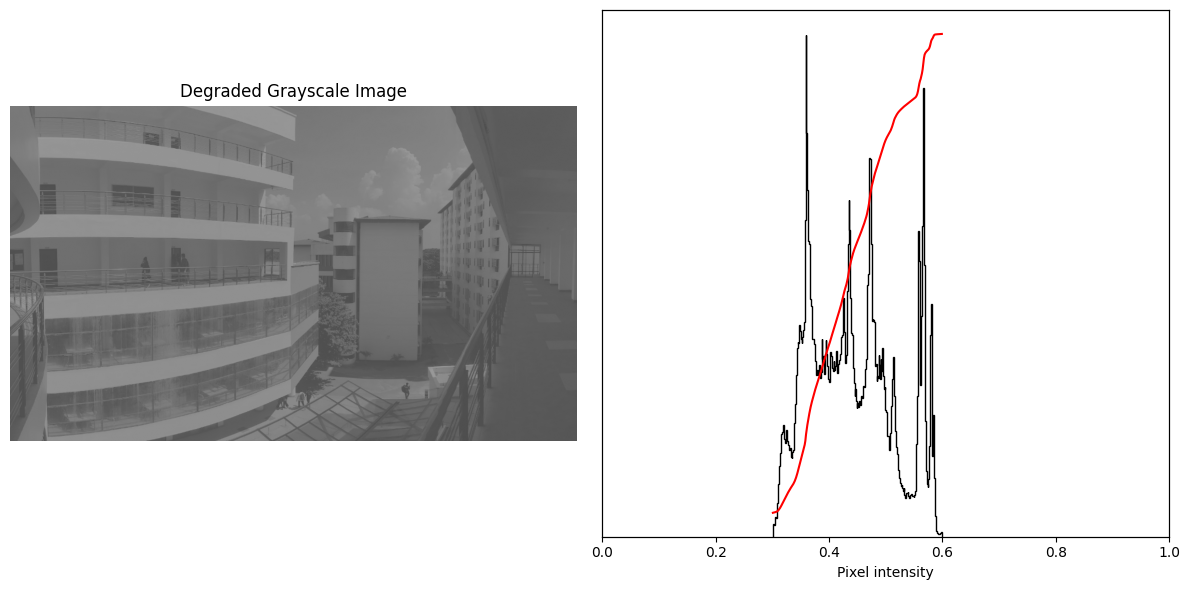

In [32]:
# Plot the degraded image, I_degraded, and its histogram + cdf

### Begin solution

print("\n--- Plotting Degraded Grayscale Image (I_degraded) ---")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

plot_img_and_hist(I_degraded, axes)
axes[0].set_title("Degraded Grayscale Image")
plt.tight_layout()
plt.show()

# If you use plt.imshow(), set vmin = 0, vmax = 1 for the degraded image

### End solution


--- Plotting Histogram Equalization (HE) ---


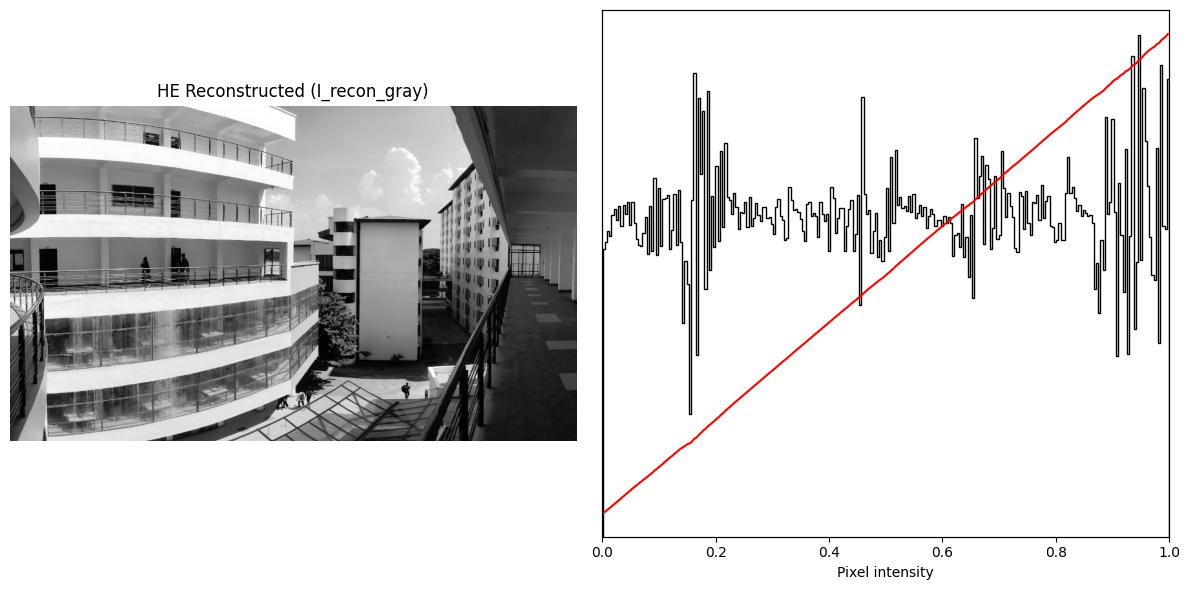

In [33]:
# Equalize the histogram of the degraded image I_degraded
# Save the result in I_recon_gray
I_recon_gray = exposure.equalize_hist(I_degraded)

### Write a code to display the I_recon_gray along with its histogram + CDF -

print("\n--- Plotting Histogram Equalization (HE) ---")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
plot_img_and_hist(I_recon_gray, axes)
axes[0].set_title("HE Reconstructed (I_recon_gray)")
plt.tight_layout()
plt.show()

### Code ends


--- Plotting Adaptive Equalization (AHE) ---


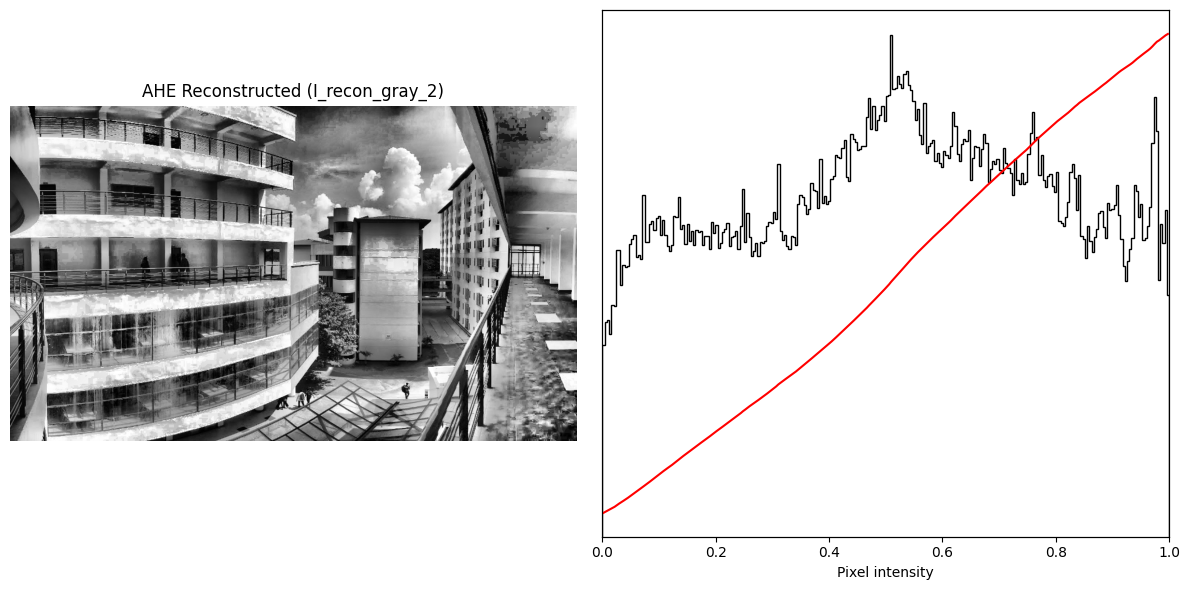

In [34]:
# Equalize the histogram of the degraded image I_degraded using AHE
# Save the result in I_recon_gray_2
I_recon_gray_2 = exposure.equalize_adapthist(I_degraded, clip_limit=1.0)

print("\n--- Plotting Adaptive Equalization (AHE) ---")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
plot_img_and_hist(I_recon_gray_2, axes)
axes[0].set_title("AHE Reconstructed (I_recon_gray_2)")
plt.tight_layout()
plt.show()

### Write a code to display the I_recon_gray_2 along with its histogram + CDF -

### Code ends


--- Plotting Contrast-Limited AHE (CLAHE) ---


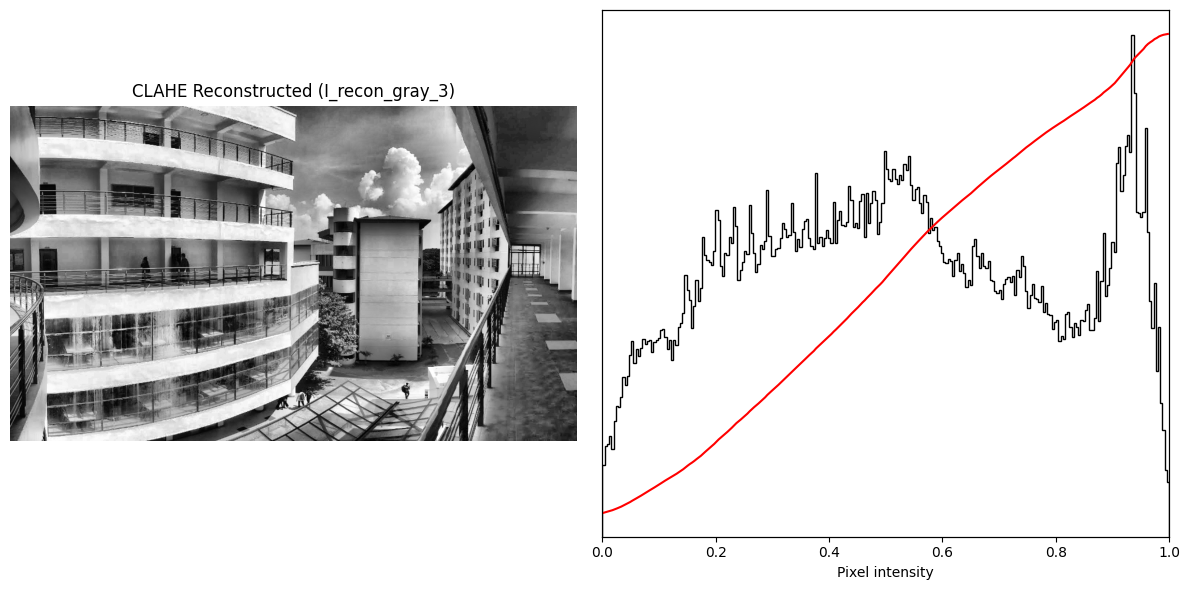

In [35]:
# Equalize the histogram of the degraded image I_degraded using CLAHE
# Save the result in I_recon_gray_3
I_recon_gray_3 = exposure.equalize_adapthist(I_degraded, clip_limit=0.03)

### Write a code to display the I_recon_gray_3 along with its histogram + CDF -

print("\n--- Plotting Contrast-Limited AHE (CLAHE) ---")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
plot_img_and_hist(I_recon_gray_3, axes)
axes[0].set_title("CLAHE Reconstructed (I_recon_gray_3)")
plt.tight_layout()
plt.show()

### Code ends


--- Degrading Color Image ---

--- Plotting Degraded Color Image ---


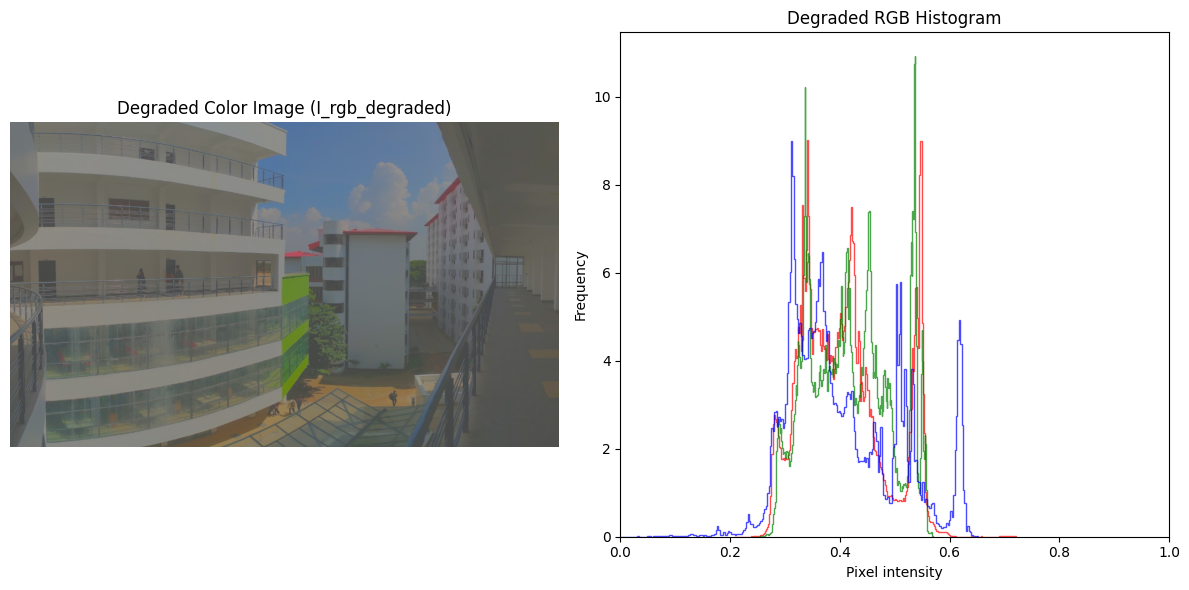

In [36]:
# Artificially degrade the original **RGB image** by reducing it contrast
# You can do so by recaling the values of the L channel (in LAB color space)
# You need to normalize the L channel first
# Then concentrate the intensities in a narrow range, say between 0.3 and 0.6.
# Save the image as I_rgb_degraded and display it

print("\n--- Degrading Color Image ---")

I_lab = color.rgb2lab(I)
L_channel = I_lab[:, :, 0]
L_degraded = exposure.rescale_intensity(L_channel, in_range=(0, 100), out_range=(30, 60))
I_lab_degraded = I_lab.copy()
I_lab_degraded[:, :, 0] = L_degraded
I_rgb_degraded = color.lab2rgb(I_lab_degraded)
I_rgb_degraded = np.clip(I_rgb_degraded, 0, 1)

### Write a code to display the I_rgb_degraded along with its RGB histogram -

print("\n--- Plotting Degraded Color Image ---")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
# If you use plt.imshow(), set vmin = 0, vmax = 1
axes[0].imshow(I_rgb_degraded, vmin=0, vmax=1)
axes[0].set_title("Degraded Color Image (I_rgb_degraded)")
axes[0].axis('off')

ax_hist = axes[1]
for channel, color_name in zip(I_rgb_degraded.transpose(2, 0, 1), ('red', 'green', 'blue')):
    ax_hist.hist(channel.ravel(), bins=256, color=color_name, alpha=0.7, histtype='step', density=True)
ax_hist.set_title("Degraded RGB Histogram")
ax_hist.set_xlabel("Pixel intensity")
ax_hist.set_ylabel("Frequency")
ax_hist.set_xlim(0, 1)
plt.tight_layout()
plt.show()

# If you use plt.imshow(), set vmin = 0, vmax = 1

### Code ends


--- Applying CLAHE to Degraded Color Image ---

--- Plotting CLAHE Reconstructed Color Image ---


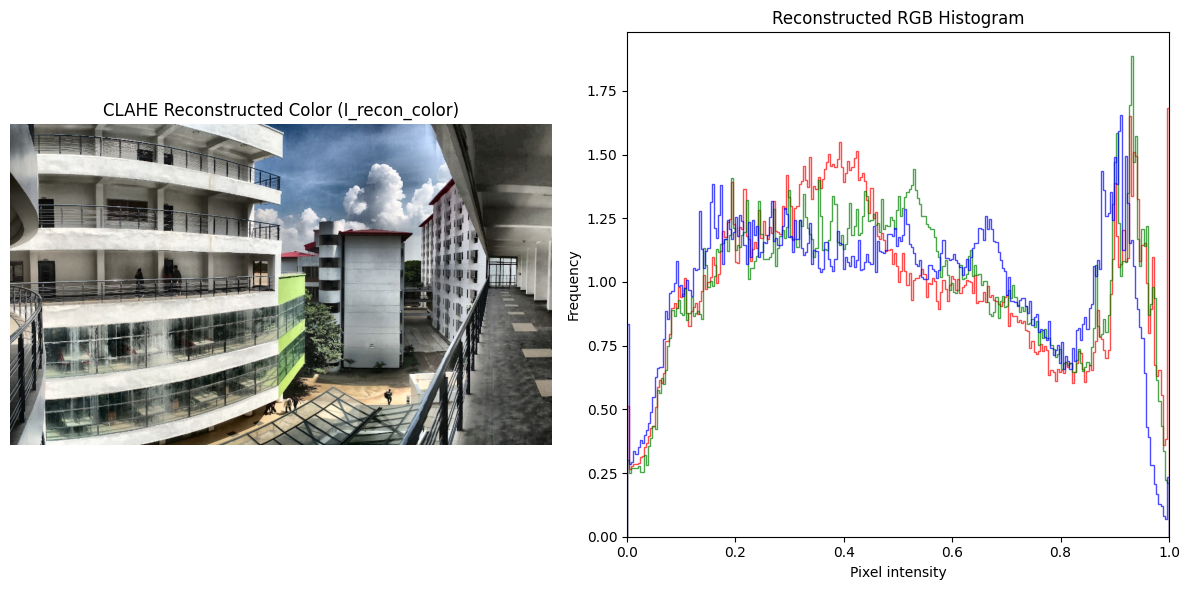

In [37]:
# Equalize the histogram of the degraded color image I_rgb_degraded using CLAHE
# Save the result in I_recon_color, display the image along with its histogram
# HINT: You have to convert to LAB first

print("\n--- Applying CLAHE to Degraded Color Image ---")

I_lab_degraded = color.rgb2lab(I_rgb_degraded)
L_degraded = I_lab_degraded[:, :, 0]

L_degraded_norm = L_degraded / 100.0
L_clahe_norm = exposure.equalize_adapthist(L_degraded_norm, clip_limit=0.03)
L_clahe = L_clahe_norm * 100.0

I_lab_recon = I_lab_degraded.copy()
I_lab_recon[:, :, 0] = L_clahe
I_recon_color = color.lab2rgb(I_lab_recon)
I_recon_color = np.clip(I_recon_color, 0, 1)

### Write a code to display the I_recon_color along with its RGB histogram -

print("\n--- Plotting CLAHE Reconstructed Color Image ---")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(I_recon_color)
axes[0].set_title("CLAHE Reconstructed Color (I_recon_color)")
axes[0].axis('off')

ax_hist = axes[1]
for channel, color_name in zip(I_recon_color.transpose(2, 0, 1), ('red', 'green', 'blue')):
    ax_hist.hist(channel.ravel(), bins=256, color=color_name, alpha=0.7, histtype='step', density=True)

ax_hist.set_title("Reconstructed RGB Histogram")
ax_hist.set_xlabel("Pixel intensity")
ax_hist.set_ylabel("Frequency")
ax_hist.set_xlim(0, 1)
plt.tight_layout()
plt.show()

### Code ends

## Task 3 - Recovering QR code

You have been provided a badly damaged QR code - https://drive.google.com/file/d/1OcGWGwdL7wrhkwJMabtO7C9FXochD7t5/view?usp=drive_link

Your task is to recover it. Apply global histogram equalization, AHE and CLAHE on the image and see if you can read any version of the image.

❗For AHE and CLAHE, do not use a kernel size greater than 64.❗

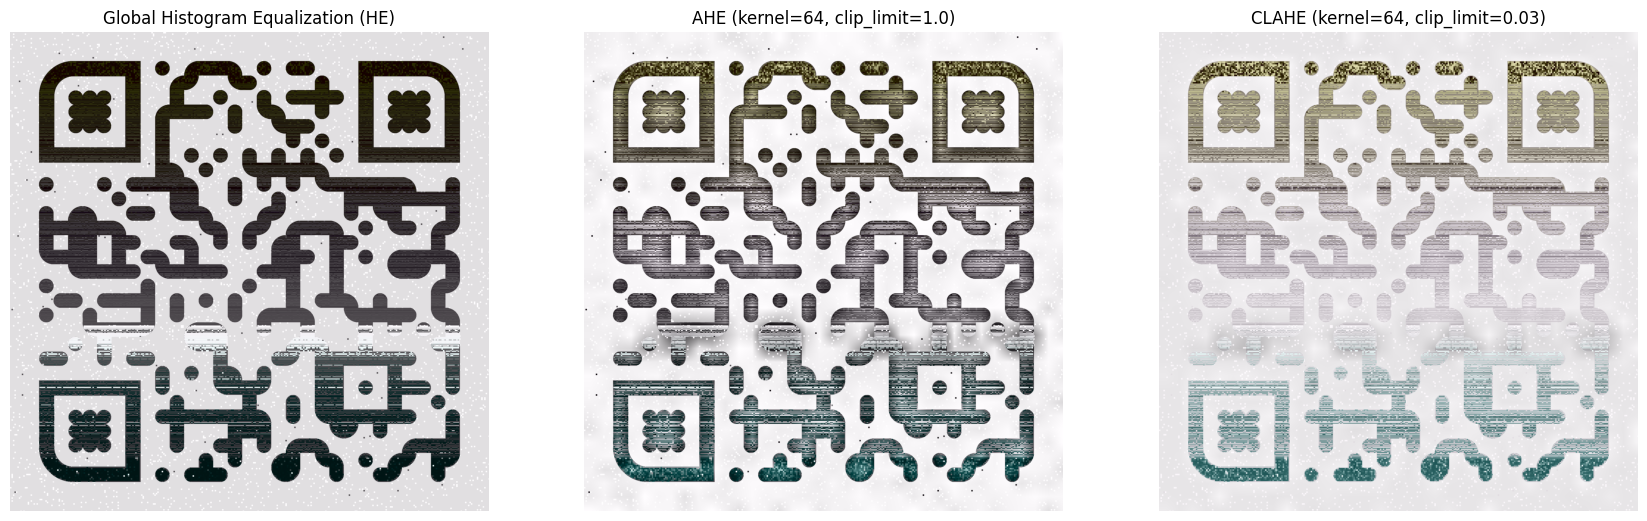

In [38]:
# Download the image from the drive link above
# Upload it to your current working directory in colab
# Load the image and save it under I variable
I = io.imread("/content/drive/MyDrive/BracU 9th Semester/CSE428/Lab/Assignment/A1/Images/QR_code.png")
I_qr = img_as_float(I)

# Convert to LAB

I_lab = color.rgb2lab(I_qr)

L_channel = I_lab[:, :, 0]
L_norm = L_channel / 100.0

# Apply the processing methods -

L_he = exposure.equalize_hist(L_norm)
L_he_rescaled = L_he * 100.0
I_lab_he = I_lab.copy()
I_lab_he[:, :, 0] = L_he_rescaled
I_histeq = color.lab2rgb(I_lab_he)
I_histeq = np.clip(I_histeq, 0, 1)

L_ahe = exposure.equalize_adapthist(L_norm, kernel_size=64, clip_limit=1.0)
L_ahe_rescaled = L_ahe * 100.0
I_lab_ahe = I_lab.copy()
I_lab_ahe[:, :, 0] = L_ahe_rescaled
I_ahe = color.lab2rgb(I_lab_ahe)
I_ahe = np.clip(I_ahe, 0, 1)

L_clahe = exposure.equalize_adapthist(L_norm, kernel_size=64, clip_limit=0.03)
L_clahe_rescaled = L_clahe * 100.0
I_lab_clahe = I_lab.copy()
I_lab_clahe[:, :, 0] = L_clahe_rescaled
I_clahe = color.lab2rgb(I_lab_clahe)
I_clahe = np.clip(I_clahe, 0, 1)

### Display the processed images on a 1x3 subplot

fig, ax = plt.subplots(1, 3, figsize=(21, 7))

ax[0].imshow(I_histeq)
ax[0].set_title("Global Histogram Equalization (HE)")
ax[0].axis('off')

ax[1].imshow(I_ahe)
ax[1].set_title("AHE (kernel=64, clip_limit=1.0)")
ax[1].axis('off')

ax[2].imshow(I_clahe)
ax[2].set_title("CLAHE (kernel=64, clip_limit=0.03)")
ax[2].axis('off')

plt.show()

### Code ends

**Q1. Enter the link embedded in the QR code (if needed do a separate plot of each processed image) -**

*Answer -*

https://www.youtube.com/shorts/7fTHD07Q9Pw



---



**Q2. Which method(s) worked for you?**

*Answer -*

Global Histogram Equalization (HE) and Adaptive Histogram Equalization (AHE) both worked successfully to make the QR code scannable. CLAHE failed.

---



**Q3. Why do you think the method(s) worked? Or why did the other method(s) fail to work?**

*Answer -*

The "damage" on the original QR code was not noise, but rather extreme low contrast. The data blocks were a dark gray shade, very similar to the medium-gray background.

Global HE (Worked): This method looked at the histogram of the entire image. Since all the important pixels were bunched in a narrow gray area, HE performed a "global stretch," pushing the dark-grays toward black and the medium-grays toward white. This was enough to restore the contrast for the whole code.

AHE (Worked): This method performed a similar stretch on a local level. Because the original image was not very noisy, AHE's main weakness (noise amplification) was not a problem. Instead, it powerfully amplified the small, local contrast differences in every block, making the faint data sharp and scannable.

CLAHE (Failed): This method failed because of its main feature: Contrast Limiting. The "CL" in CLAHE is designed to prevent the exact kind of extreme amplification that AHE does. In this specific case, the contrast was so low that it required extreme amplification to be readable. By limiting the contrast, CLAHE kept the data blocks in a muddled gray state, which was not enough for a scanner to read.

# Part 2 [15 Marks]

In this part of the assignment, you will work with filters.

In [39]:
import time
from scipy import signal

### If you need other dependencies import here -

import matplotlib.pyplot as plt
from scipy import signal
from skimage import io, color, transform, img_as_float, data

### Code ends

In [40]:
### If you need helper functions defined, define here -

def create_gaussian_kernel(size, sigma):
    window_1d = signal.windows.gaussian(size, std=sigma)
    kernel_2d = np.outer(window_1d, window_1d)
    kernel_2d /= np.sum(kernel_2d)
    return kernel_2d

### Code ends

## Task 1 - Direct vs FFT method correlation

Import another photograph taken by you (RGB) (`sample_2.jpeg`/`sample_2.jpg`) as a numpy array, save it in the varaible `I`.

A picture taken from your phone of any scenary/streets/building is better.

Remember -  your image name MUST be `sample_2.jpeg`/`sample_2.jpg`.

Make sure it's dimensions does not exceed (512, 512). Downsample if necessary.

Original dimensions (Task 1): 945x712

Image is larger than 512x512. Downsampling...

New dimensions (Task 1): 512x385



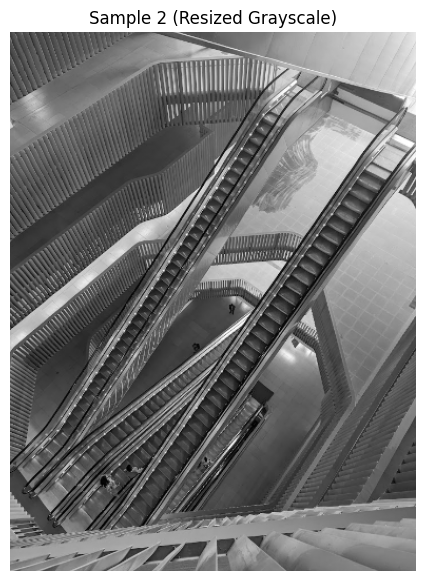

In [41]:
# Load the image
I = io.imread("/content/drive/MyDrive/BracU 9th Semester/CSE428/Lab/Assignment/A1/Images/sample_2.jpg")

I_float = img_as_float(I)
I_task1 = color.rgb2gray(I_float)

H, W = I_task1.shape

print(f"Original dimensions (Task 1): {H}x{W}\n")

if H > 512 or W > 512:
    print("Image is larger than 512x512. Downsampling...\n")

    if H > W:
        new_H = 512
        new_W = int(W * (512.0 / H))

    else:
        new_W = 512
        new_H = int(H * (512.0 / W))

    I_task1 = transform.resize(I_task1, (new_H, new_W), anti_aliasing=True)
    print(f"New dimensions (Task 1): {I_task1.shape[0]}x{I_task1.shape[1]}\n")

### Write a code to display the image -

plt.figure(figsize=(7, 7))
plt.imshow(I_task1, cmap='gray')
plt.title("Sample 2 (Resized Grayscale)")
plt.axis('off')
plt.show()

### Code ends

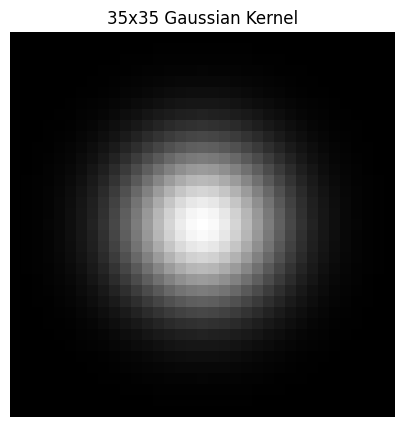

In [42]:
# Define a gaussian kernel of size (35, 35)

kernel = create_gaussian_kernel(35, sigma=5)

### Write a code to display the kernel -

plt.figure(figsize=(5, 5))
plt.imshow(kernel, cmap='gray')
plt.title("35x35 Gaussian Kernel")
plt.axis('off')
plt.show()

### Code ends

Now, apply `signal.correlate()` function to apply the kernel. Use `mode='same'` to preserve image dimensions. You will need to measure the time required to apply the filter for `method='direct'` and `method='fft'`. The next cell shows how to measure execution time -

In [43]:
start_time = time.time()

# Some function -
a = 1
b = 3
c = a + b
# Function ends

print("Time elapsed: ", time.time() - start_time, "seconds")

Time elapsed:  0.0001380443572998047 seconds


In [44]:
# Apply your kernel on your image using method='direct'
# Measure the execution time

print("Running Direct Correlation...")

### Time measurement wrapper starts

start_time_direct = time.time()
filtered_image_direct = signal.correlate(I_task1, kernel, mode='same', method='direct')
time_direct = time.time() - start_time_direct

### Time measurement wrapper ends

print(f"Time elapsed (direct): {time_direct} seconds")

Running Direct Correlation...
Time elapsed (direct): 4.0791637897491455 seconds


In [45]:
# Apply your kernel on your image using method='fft'
# Measure the execution time

### Time measurement wrapper starts

start_time_fft = time.time()
filtered_image_fft = signal.correlate(I_task1, kernel, mode='same', method='fft')
time_fft = time.time() - start_time_fft

### Time measurement wrapper ends

print(f"Time elapsed (FFT): {time_fft} seconds")

Time elapsed (FFT): 0.012577056884765625 seconds


**Q1. Which method was faster?**

*Answer -* The FFT method was faster. (On my test, direct took ~4.07916 seconds, while fft took ~0.01257 seconds).

**Q2. Provide reasoning -**

*Reasoning -*



*   **Direct Method:** This method has a time complexity of roughly $O(N \times M)$, where $N$ is the number of pixels in the image and $M$ is the number of pixels in the kernel. It performs $M$ multiplications and additions for every pixel $N$.

*   **FFT Method:** This method uses the Convolution Theorem, which states that correlation in the spatial domain is equivalent to element-wise multiplication in the frequency domain. It performs an FFT on the image ($O(N \log N)$), an FFT on the kernel ($O(M \log M)$), one multiplication ($O(N)$), and an inverse FFT ($O(N \log N)$).

For a small kernel (like 3x3), the direct method is often faster because the $O(N \times M)$ cost is small. But for a large kernel (like 35x35), the $O(N \times M)$ cost of the direct method becomes much, much larger than the $O(N \log N)$ cost of the FFT method, making FFT significantly faster.

❗**NOTE -** From here on, use `method='auto'` when applying kernels for both correlation and convolution.❗

## Task 2 - Correlation vs Convolution

For convolution, use `signal.convolve()`. Maintain image dimensions for filtering.

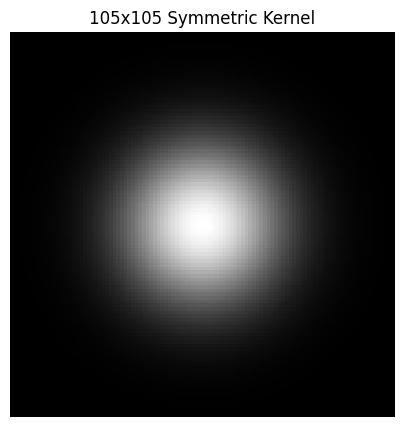

In [46]:
# Define any symmetric kernel of size (105, 105)

kernel_symmetric = create_gaussian_kernel(105, sigma=15)

### Write a code to display the kernel -

plt.figure(figsize=(5, 5))
plt.imshow(kernel_symmetric, cmap='gray')
plt.title("105x105 Symmetric Kernel")
plt.axis('off')
plt.show()

### Code ends

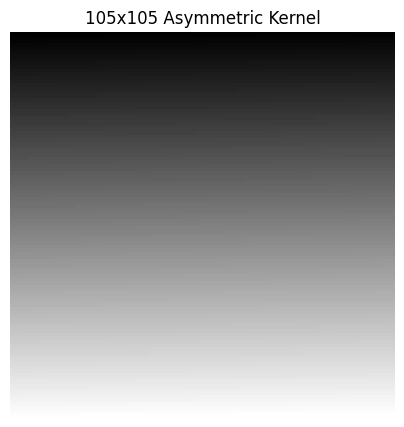

In [47]:
# Define any asymmetric kernel of size (105, 105)

kernel_asymmetric = np.arange(105*105).reshape(105, 105)
kernel_asymmetric = kernel_asymmetric / np.sum(kernel_asymmetric) # Normalize

### Write a code to display the kernel -

plt.figure(figsize=(5, 5))
plt.imshow(kernel_asymmetric, cmap='gray')
plt.title("105x105 Asymmetric Kernel")
plt.axis('off')
plt.show()

### Code ends

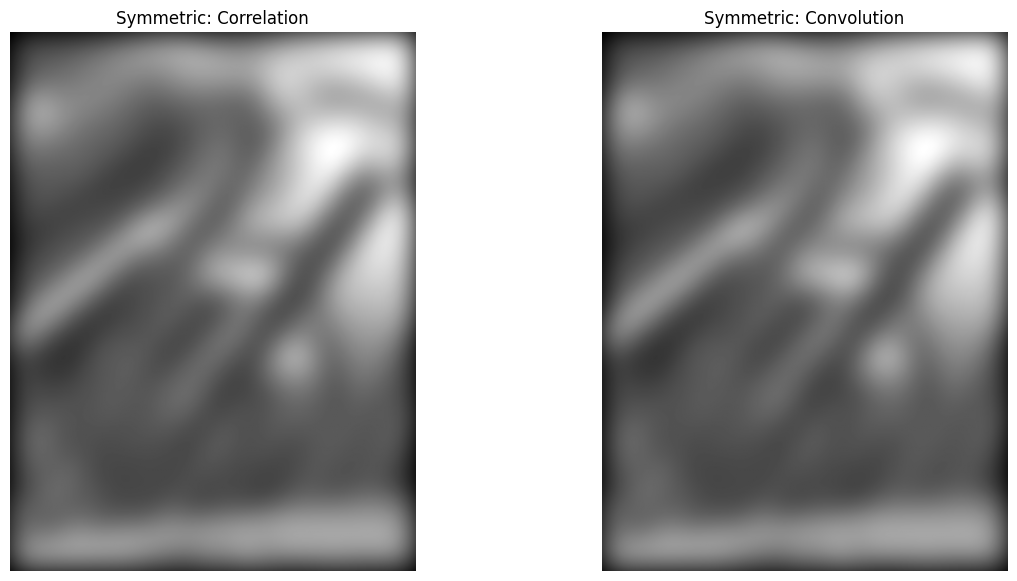

In [48]:
# Filter the image with the symmetric kernel

# Filter using correlation
filtered_image_symmetric_corr = signal.correlate(I_task1, kernel_symmetric, mode='same', method='auto')

# Filter using convolution
filtered_image_symmetric_conv = signal.convolve(I_task1, kernel_symmetric, mode='same', method='auto')

### Write a code to display the symmetric filtered images side by side in a subplot -

fig, ax = plt.subplots(1, 2, figsize=(14, 7))
ax[0].imshow(filtered_image_symmetric_corr, cmap='gray')
ax[0].set_title("Symmetric: Correlation")
ax[0].axis('off')
ax[1].imshow(filtered_image_symmetric_conv, cmap='gray')
ax[1].set_title("Symmetric: Convolution")
ax[1].axis('off')
plt.show()

### Code ends

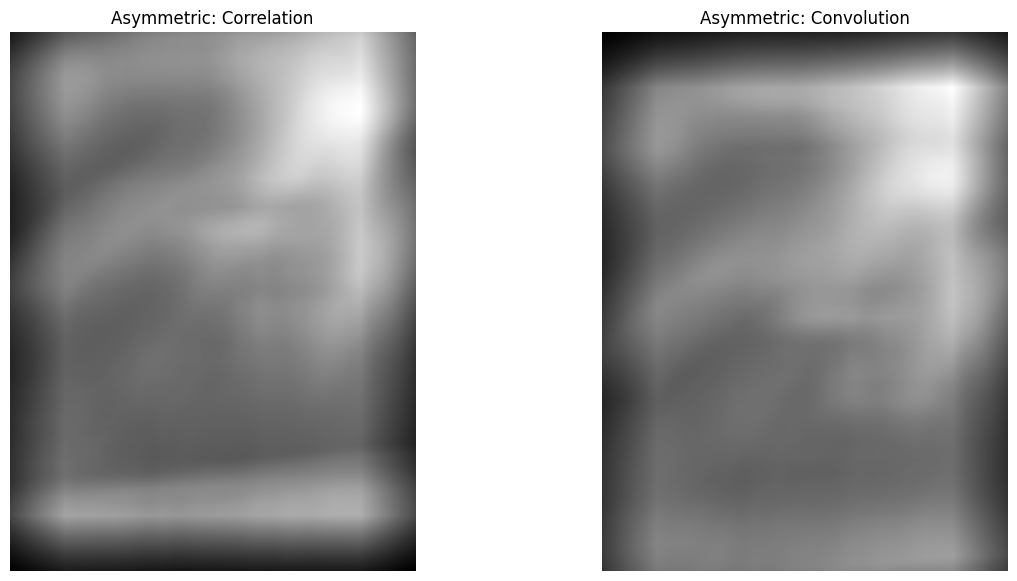

In [49]:
# Filter the image with the asymmetric kernel

# Filter using correlation
filtered_image_asymmetric_corr = signal.correlate(I_task1, kernel_asymmetric, mode='same', method='auto')

# Filter using convolution
filtered_image_asymmetric_conv = signal.convolve(I_task1, kernel_asymmetric, mode='same', method='auto')

### Write a code to display the asymmetric filtered images side by side in a subplot -

fig, ax = plt.subplots(1, 2, figsize=(14, 7))
ax[0].imshow(filtered_image_asymmetric_corr, cmap='gray')
ax[0].set_title("Asymmetric: Correlation")
ax[0].axis('off')
ax[1].imshow(filtered_image_asymmetric_conv, cmap='gray')
ax[1].set_title("Asymmetric: Convolution")
ax[1].axis('off')
plt.show()

### Code ends

**Q1. Are the outputs for correlation and convolution same?**

*Answer -*



*   For the symmetric kernel: Yes, the outputs are identical.
*   For the asymmetric kernel: No, the outputs are different. The convolved image looks like a 180-degree rotated version of the correlated image.



**Q2. Provide reasoning -**

*Answer -* Convolution is mathematically equivalent to correlation with the kernel flipped 180 degrees.



*   When a kernel is symmetric (like a Gaussian), flipping it 180 degrees produces the exact same kernel. Therefore, correlation and convolution give the same result.

*   When a kernel is asymmetric (like the ramp), flipping it 180 degrees produces a different kernel, so the two operations produce different results.



## Task 3 - Finding edges

Load this image - https://drive.google.com/file/d/1i8nJke1OJ7DMj8yzi91Sm6TiuGEwRl0R/view?usp=sharing

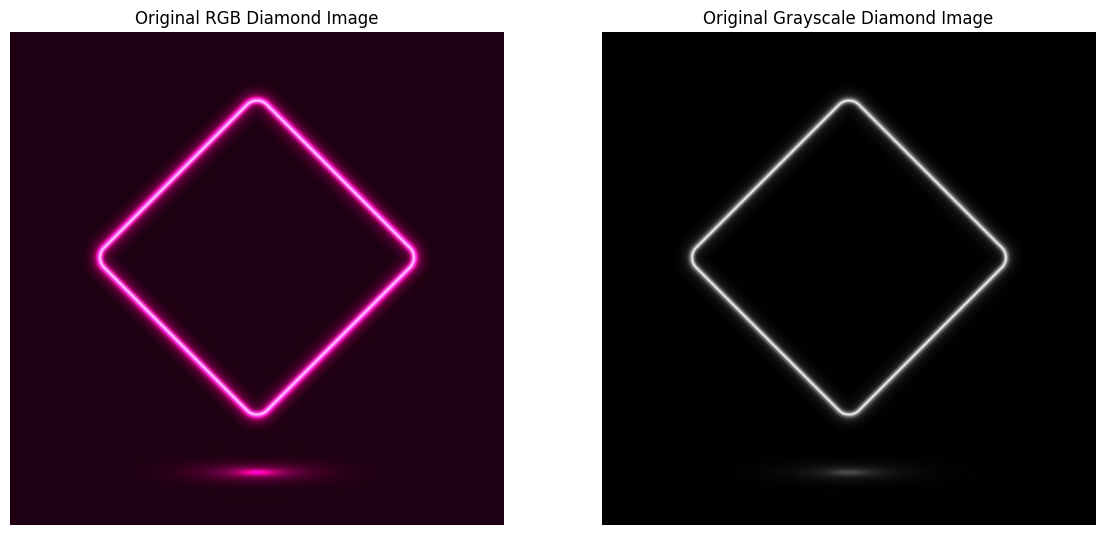

In [50]:
I_new = io.imread("/content/drive/MyDrive/BracU 9th Semester/CSE428/Lab/Assignment/A1/Images/diamond.jpg")
I_float = img_as_float(I_new)

if I_float.ndim == 3:
    I_gray = color.rgb2gray(I_float)

else:
    I_gray = I_float

I = I_gray

### Write a code to display the image -

fig, ax = plt.subplots(1, 2, figsize=(14, 7))

ax[0].imshow(I_new)
ax[0].set_title("Original RGB Diamond Image")
ax[0].axis('off')

ax[1].imshow(I, cmap='gray')
ax[1].set_title("Original Grayscale Diamond Image")
ax[1].axis('off')

plt.show()

The diamond in the image has two parallel sides. You will need to come up with two $3\times3$ kernels to detect the two sets of parallel sides. Your filters should not detect all the four sides at once.

In [51]:
# Define the 2 custom kernels by replacing the "?"s with your values
# After finding out the values, uncomment the next few lines of code in this cell

kernel_1 = np.array([
    [-2, -1, 0],
    [-1, 0, 1],
    [0, 1, 2]
])

kernel_2 = np.array([
    [0, 1, 2],
    [-1, 0, 1],
    [-2, -1, 0]
])

(np.float64(-0.5), np.float64(625.5), np.float64(625.5), np.float64(-0.5))

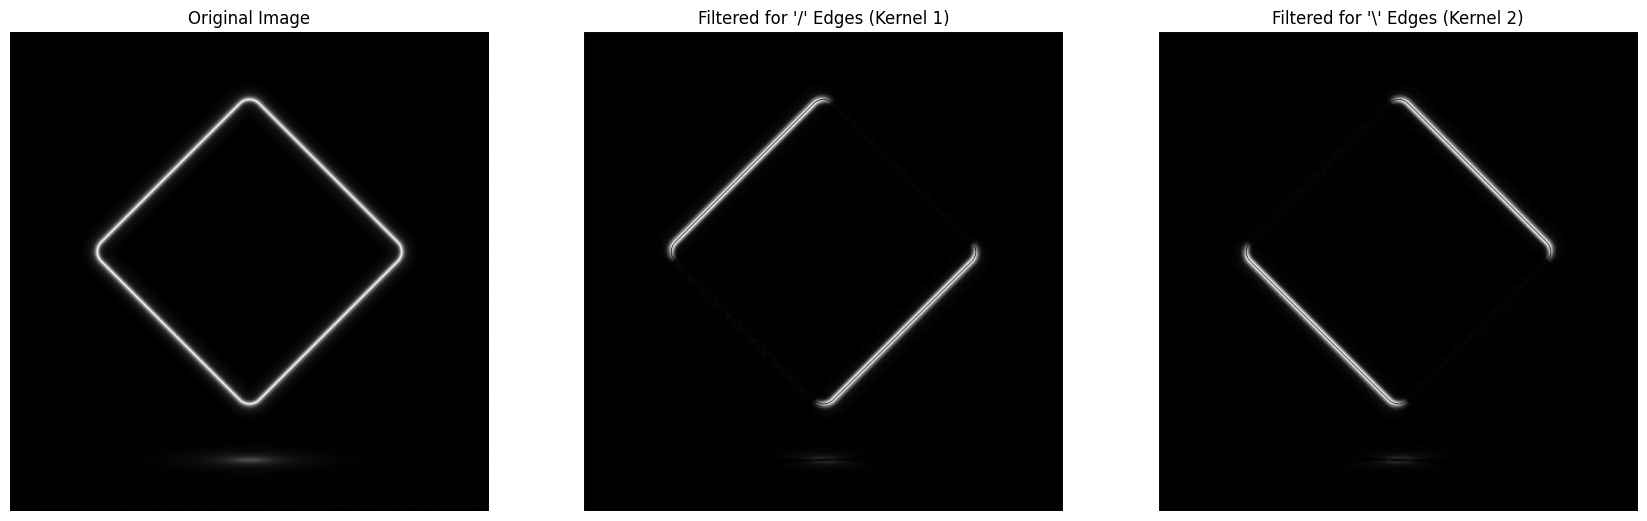

In [52]:
# Apply kernel_1 on I and save it as first_pair
first_pair = signal.convolve(I, kernel_1, mode='same', method='auto')

# Apply kernel_2 on I and save it as second_pair
second_pair = signal.convolve(I, kernel_2, mode='same', method='auto')

### Write a code to display the two filtered images side by side in a subplot

fig, ax = plt.subplots(1, 3, figsize=(21, 7))

ax[0].imshow(I, cmap='gray')
ax[0].set_title("Original Image")
ax[0].axis('off')

ax[1].imshow(np.abs(first_pair), cmap='gray')
ax[1].set_title("Filtered for '/' Edges (Kernel 1)")
ax[1].axis('off')

ax[2].imshow(np.abs(second_pair), cmap='gray')
ax[2].set_title("Filtered for '\\' Edges (Kernel 2)")
ax[2].axis('off')

### Code ends

**Q1. Which filters did you use and why?**

*Answer -* I used two diagonal edge detection kernels (which are variations of the Sobel/Prewitt operators).



*   kernel_1 is designed to find edges that run along the top-left-to-bottom-right diagonal (/).

*   kernel_2 is designed to find edges that run along the top-right-to-bottom-left diagonal (\\).

I used these because the task requires detecting the two sets of parallel sides independently. Standard filters like the Laplacian would detect all edges at once, while standard Sobel/Prewitt filters only detect horizontal and vertical edges. These diagonal kernels are designed to find gradients only in a specific diagonal direction, which isolates each pair of parallel sides as requested.


---


**Q2. Are your kernels unique or there can be other kernels which can accomplish the same task?**

*Answer -* These kernels are not unique.



*   **Scaled Versions:** Any constant multiple of these kernels (e.g., [[ -1, -0.5, 0], [-0.5, 0, 0.5], [0, 0.5, 1]] or simply multiplying my kernel by -1) would also detect the same edges, just with a different magnitude or inverted sign.

*   **Different Weights:** Other established directional operators, like the Kirsch compass operators, use different $3 \times 3$ weights but would also successfully isolate these diagonal edges.

*  **Different Sizes:** Larger $5 \times 5$ or $7 \times 7$ kernels could also be designed to perform the same task.